--- GridSearchCV Tuning Results ---
Best Parameters Found: {'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Accuracy: 0.9770

--- Final Model Performance on Test Set ---
Test Accuracy: 0.9750

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.95      1.00      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.97      0.89      0.93        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      

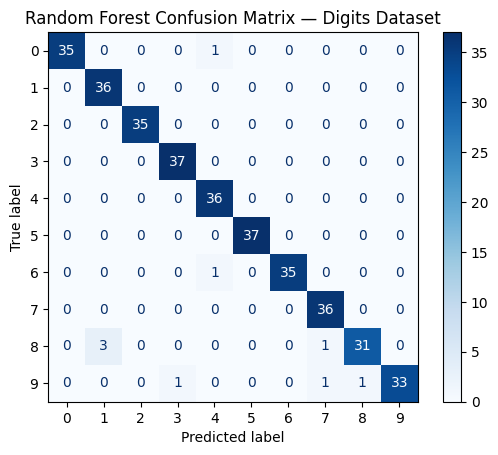

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

digits = load_digits()
X = pd.DataFrame(digits.data)  
y = pd.Series(digits.target)   

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_pipeline = Pipeline(
    steps=[
        ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
    ]
)

param_grid = {
    'model__n_estimators': [50, 100, 200],       
    'model__max_features': ['sqrt', 'log2'],     
    'model__max_depth': [10, 20, None],         
    'model__min_samples_split': [2, 5]           
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("--- GridSearchCV Tuning Results ---")
print("Best Parameters Found:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}\n")

best_rf_pipeline = grid_search.best_estimator_
y_pred = best_rf_pipeline.predict(X_test)

print("--- Final Model Performance on Test Set ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix — Digits Dataset")
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_reg_pipeline = Pipeline(
    steps=[
        ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
    ]
)

param_grid = {
    'model__n_estimators': [50, 100],
    'model__criterion': ['squared_error', 'absolute_error'],
    'model__max_features': [0.5, 'sqrt'],
    'model__max_depth': [10, None]
}

grid_search = GridSearchCV(
    estimator=rf_reg_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("--- GridSearchCV Tuning Results ---")
print("Best Parameters Found:", grid_search.best_params_)

best_rf_reg_pipeline = grid_search.best_estimator_
y_pred = best_rf_reg_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Final Model Performance on Test Set ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R² Score): {r2:.4f}\n")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices — California Housing')
plt.show()

KeyboardInterrupt: 